# Covid-19 Analysis
## Data cleaning, Data transformation using python

### Importing all the necessary libraries

In [1]:
import os 
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from math import sqrt
from datetime import datetime

%matplotlib inline

### Importing dataset


In [2]:

raw_data_confirmed = pd.read_csv('time_series_covid19_confirmed_global.csv')
raw_data_deaths = pd.read_csv('time_series_covid19_deaths_global.csv')
raw_data_Recovered = pd.read_csv('time_series_covid19_recovered_global.csv')

print("The Shape of confirmed is: ", raw_data_confirmed.shape)
print("The Shape of deaths is: ", raw_data_deaths.shape)
print("The Shape of recovered is: ", raw_data_Recovered.shape)

raw_data_confirmed.head()

The Shape of confirmed is:  (271, 350)
The Shape of deaths is:  (271, 350)
The Shape of recovered is:  (256, 350)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,50433,50655,50810,50886,51039,51280,51350,51405,51526,51526
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,54317,54827,55380,55755,56254,56572,57146,57727,58316,58316
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,96549,97007,97441,97857,98249,98631,98988,99311,99610,99897
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,7669,7699,7756,7806,7821,7875,7919,7983,8049,8117
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,16931,17029,17099,17149,17240,17296,17371,17433,17553,17568


In [3]:
raw_data_confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,50433,50655,50810,50886,51039,51280,51350,51405,51526,51526
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,54317,54827,55380,55755,56254,56572,57146,57727,58316,58316
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,96549,97007,97441,97857,98249,98631,98988,99311,99610,99897
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,7669,7699,7756,7806,7821,7875,7919,7983,8049,8117
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,16931,17029,17099,17149,17240,17296,17371,17433,17553,17568


In [4]:
raw_data_deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2117,2126,2139,2149,2160,2174,2179,2181,2191,2191
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,1117,1125,1134,1143,1153,1164,1170,1174,1181,1181
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,2696,2705,2716,2722,2728,2737,2745,2751,2756,2762
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,82,83,83,83,83,83,84,84,84,84
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,393,393,396,399,399,403,403,405,405,405


In [5]:
raw_data_Recovered.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/23/20,12/24/20,12/25/20,12/26/20,12/27/20,12/28/20,12/29/20,12/30/20,12/31/20,1/1/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,39692,40359,40444,40784,41096,41441,41543,41612,41727,41727
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,29799,30276,30790,31181,31565,32122,32700,33185,33634,33634
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,64401,64777,65144,65505,65862,66214,66550,66855,67127,67395
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,7106,7171,7203,7252,7288,7318,7360,7384,7432,7463
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,9729,9729,9921,9976,10354,10354,10627,10859,11044,11146


### Un-Pivoting the data

In [6]:
raw_data_confirmed2 = pd.melt(raw_data_confirmed, id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], 
                              var_name=['Date'])
raw_data_deaths2 = pd.melt(raw_data_deaths, id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], 
                           var_name=['Date'])
raw_data_Recovered2 = pd.melt(raw_data_Recovered, id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], 
                              var_name=['Date'])


print("The Shape of Confirmed is: ", raw_data_confirmed2.shape)
print("The Shape of deaths is: ", raw_data_deaths2.shape)
print("The Shape of recovered is: ", raw_data_Recovered2.shape)


raw_data_confirmed2

The Shape of Confirmed is:  (93766, 6)
The Shape of deaths is:  (93766, 6)
The Shape of recovered is:  (88576, 6)


,Province/State,Country/Region,Lat,Long,Date,value
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
93761,NaN,Vietnam,14.058324,108.277199,1/1/21,1474
93762,NaN,West Bank and Gaza,31.952200,35.233200,1/1/21,139223
93763,NaN,Yemen,15.552727,48.516388,1/1/21,2101
93764,NaN,Zambia,-13.133897,27.849332,1/1/21,20997


In [7]:
raw_data_confirmed2.head()

,Province/State,Country/Region,Lat,Long,Date,value
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


### Converting the new column to dates


In [8]:
raw_data_confirmed2['Date'] = pd.to_datetime(raw_data_confirmed2['Date'])
raw_data_deaths2['Date'] = pd.to_datetime(raw_data_deaths2['Date'])
raw_data_Recovered2['Date'] = pd.to_datetime(raw_data_Recovered2['Date'])

C:\Users\kaurs\AppData\Local\Temp\ipykernel_12348\2164032187.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data_confirmed2['Date'] = pd.to_datetime(raw_data_confirmed2['Date'])
C:\Users\kaurs\AppData\Local\Temp\ipykernel_12348\2164032187.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data_deaths2['Date'] = pd.to_datetime(raw_data_deaths2['Date'])
C:\Users\kaurs\AppData\Local\Temp\ipykernel_12348\2164032187.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  raw_data_Recovered2['Date'] = pd.to_datetime(raw_data_Recovered2['Date'])


### Renaming the Values


In [9]:
raw_data_confirmed2.columns = raw_data_confirmed2.columns.str.replace('value', 'Confirmed')
raw_data_deaths2.columns = raw_data_deaths2.columns.str.replace('value', 'Deaths')
raw_data_Recovered2.columns = raw_data_Recovered2.columns.str.replace('value', 'Recovered')

In [10]:
raw_data_confirmed2.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0
1,NaN,Albania,41.15330,20.168300,2020-01-22,0
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0


### Investigating the NULL values

In [11]:
raw_data_Recovered2.isnull().sum()

Province/State    65394
Country/Region        0
Lat                   0
Long                  0
Date                  0
Recovered             0
dtype: int64

### Dealing with NULL values

In [12]:
raw_data_confirmed2['Province/State'].fillna(raw_data_confirmed2['Country/Region'], inplace=True)
raw_data_deaths2['Province/State'].fillna(raw_data_deaths2['Country/Region'], inplace=True)
raw_data_Recovered2['Province/State'].fillna(raw_data_Recovered2['Country/Region'], inplace=True)

In [13]:
raw_data_Recovered2.isnull().sum()

Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Recovered         0
dtype: int64

### printing shapes before the join

In [14]:
print("The Shape of confirmed is: ", raw_data_confirmed2.shape)
print("The Shape of deaths is: ", raw_data_deaths2.shape)
print("The Shape of recovered is: ", raw_data_Recovered2.shape)

The Shape of confirmed is:  (93766, 6)
The Shape of deaths is:  (93766, 6)
The Shape of recovered is:  (88576, 6)


In [15]:
raw_data_confirmed2

,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,Afghanistan,Afghanistan,33.939110,67.709953,2020-01-22,0
1,Albania,Albania,41.153300,20.168300,2020-01-22,0
2,Algeria,Algeria,28.033900,1.659600,2020-01-22,0
3,Andorra,Andorra,42.506300,1.521800,2020-01-22,0
4,Angola,Angola,-11.202700,17.873900,2020-01-22,0
...,...,...,...,...,...,...
93761,Vietnam,Vietnam,14.058324,108.277199,2021-01-01,1474
93762,West Bank and Gaza,West Bank and Gaza,31.952200,35.233200,2021-01-01,139223
93763,Yemen,Yemen,15.552727,48.516388,2021-01-01,2101
93764,Zambia,Zambia,-13.133897,27.849332,2021-01-01,20997


In [16]:
full_join = raw_data_confirmed2.merge(raw_data_deaths2[['Province/State','Country/Region','Date','Deaths']], 
                                      how = 'left', 
                                      left_on = ['Province/State','Country/Region','Date'], 
                                      right_on = ['Province/State', 'Country/Region','Date'])
full_join.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0


In [17]:
full_join = full_join.merge(raw_data_Recovered2[['Province/State','Country/Region','Date','Recovered']], 
                                      how = 'left', 
                                      left_on = ['Province/State','Country/Region','Date'], 
                                      right_on = ['Province/State', 'Country/Region','Date'])
full_join.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0


### Adding Month and Year as a new Column

In [18]:
full_join['Month-Year'] = full_join['Date'].dt.strftime('%b-%Y')

In [19]:
full_join.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Month-Year
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0,Jan-2020
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0,Jan-2020
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0,Jan-2020
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0,Jan-2020
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0,Jan-2020


In [20]:
full_join2 = full_join.copy()

#creating a new date columns - 1
full_join2['Date - 1'] = full_join2['Date'] + pd.Timedelta(days=1)
full_join2.rename(columns={'Confirmed': 'Confirmed - 1', 'Deaths': 'Deaths - 1', 'Recovered': 'Recovered - 1',
                          'Date': 'Date Minus 1'}, inplace=True)


In [21]:
full_join2.head()

,Province/State,Country/Region,Lat,Long,Date Minus 1,Confirmed - 1,Deaths - 1,Recovered - 1,Month-Year,Date - 1
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0,Jan-2020,2020-01-23
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0,Jan-2020,2020-01-23
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0,Jan-2020,2020-01-23
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0,Jan-2020,2020-01-23
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0,Jan-2020,2020-01-23


In [22]:
full_join3 = full_join.merge(full_join2[['Province/State', 'Country/Region','Confirmed - 1', 'Deaths - 1', 
                            'Recovered - 1', 'Date - 1', 'Date Minus 1']], how = 'left',
                             left_on = ['Province/State','Country/Region','Date'], 
                             right_on = ['Province/State', 'Country/Region','Date - 1'])
full_join3.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Month-Year,Confirmed - 1,Deaths - 1,Recovered - 1,Date - 1,Date Minus 1
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT


In [23]:
full_join3['Confirmed Daily'] = full_join3['Confirmed'] - full_join3['Confirmed - 1']
full_join3['Deaths Daily'] = full_join3['Deaths'] - full_join3['Deaths - 1']
full_join3['Recovered Daily'] = full_join3['Recovered'] - full_join3['Recovered - 1']

print(full_join3.shape)

(93766, 17)


In [24]:
full_join3.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Month-Year,Confirmed - 1,Deaths - 1,Recovered - 1,Date - 1,Date Minus 1,Confirmed Daily,Deaths Daily,Recovered Daily
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN


In [25]:
#############################################################################################
######################## Braking the numbers by Day #########################################
#############################################################################################


#creating a new df    
full_join2 = full_join.copy()

#creating a new date columns - 1
full_join2['Date - 1'] = full_join2['Date'] + pd.Timedelta(days=1)
full_join2.rename(columns={'Confirmed': 'Confirmed - 1', 'Deaths': 'Deaths - 1', 'Recovered': 'Recovered - 1',
                          'Date': 'Date Minus 1'}, inplace=True)

#Joing on the 2 DFs
full_join3 = full_join.merge(full_join2[['Province/State', 'Country/Region','Confirmed - 1', 'Deaths - 1', 
                            'Recovered - 1', 'Date - 1', 'Date Minus 1']], how = 'left',
                             left_on = ['Province/State','Country/Region','Date'], 
                             right_on = ['Province/State', 'Country/Region','Date - 1'])

#minus_onedf.rename(columns={'Confirmed': 'Confirmed - 1', 'Deaths': 'Deaths - 1', 'Recovered': 'Recovered - 1'}, inplace=True)

full_join3.head()

# Additional Calculations
full_join3['Confirmed Daily'] = full_join3['Confirmed'] - full_join3['Confirmed - 1']
full_join3['Deaths Daily'] = full_join3['Deaths'] - full_join3['Deaths - 1']
full_join3['Recovered Daily'] = full_join3['Recovered'] - full_join3['Recovered - 1']

print(full_join3.shape)

(93766, 17)


In [26]:
full_join3.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Month-Year,Confirmed - 1,Deaths - 1,Recovered - 1,Date - 1,Date Minus 1,Confirmed Daily,Deaths Daily,Recovered Daily
0,Afghanistan,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
1,Albania,Albania,41.15330,20.168300,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
2,Algeria,Algeria,28.03390,1.659600,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
3,Andorra,Andorra,42.50630,1.521800,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
4,Angola,Angola,-11.20270,17.873900,2020-01-22,0,0,0.0,Jan-2020,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN


In [27]:
# Additing manually the numbers for first day


full_join3.loc[full_join3['Date'] == '2020-01-22','Confirmed Daily'] = full_join3['Confirmed']
full_join3.loc[full_join3['Date'] == '2020-01-22','Deaths Daily'] = full_join3['Deaths']
full_join3.loc[full_join3['Date'] == '2020-01-22','Recovered Daily'] = full_join3['Recovered']

# deleting columns
del full_join3['Confirmed - 1']
del full_join3['Deaths - 1']
del full_join3['Recovered - 1']
del full_join3['Date - 1']
del full_join3['Date Minus 1']

### Removing Negative values

In [28]:
full_join3[full_join3["Deaths Daily"]<0]

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Month-Year,Confirmed Daily,Deaths Daily,Recovered Daily
14778,Iceland,Iceland,64.963100,-19.020800,2020-03-16,180,0,0.0,Mar-2020,9.0,-5.0,-8.0
15653,Philippines,Philippines,12.879721,121.774017,2020-03-19,217,17,8.0,Mar-2020,15.0,-2.0,3.0
15862,Iceland,Iceland,64.963100,-19.020800,2020-03-20,409,0,5.0,Mar-2020,79.0,-1.0,0.0
16134,India,India,20.593684,78.962880,2020-03-21,330,4,23.0,Mar-2020,86.0,-1.0,3.0
16311,Quebec,Canada,52.939900,-73.549100,2020-03-22,219,4,NaN,Mar-2020,38.0,-1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
87140,Ireland,Ireland,53.142400,-7.692100,2020-12-08,74682,2097,23364.0,Dec-2020,214.0,-2.0,0.0
87259,Yemen,Yemen,15.552727,48.516388,2020-12-08,2078,606,1382.0,Dec-2020,-305.0,-43.0,-172.0
88203,France,France,46.227600,2.213700,2020-12-12,2350793,57210,152555.0,Dec-2020,-130.0,-1.0,0.0
88585,Tajikistan,Tajikistan,38.861000,71.276100,2020-12-13,12704,88,12133.0,Dec-2020,80.0,-1.0,83.0


In [29]:
full_join3['Deaths Daily']=np.where(full_join3['Deaths Daily']<0 ,0,full_join3['Deaths Daily'])

In [30]:
full_join3['Confirmed Daily']=np.where(full_join3['Confirmed Daily']<0 ,0,full_join3['Confirmed Daily'])

In [31]:
full_join3['Recovered Daily']=np.where(full_join3['Recovered Daily']<0 ,0,full_join3['Recovered Daily'])

### Exporting output file

In [32]:
path = r"C:\Users\kaurs\OneDrive\Desktop\summer internship2024\Covid-19 Analysis"

# Changing my CWD
os.chdir(path)

full_join3.to_csv('CoronaVirus Data.csv')

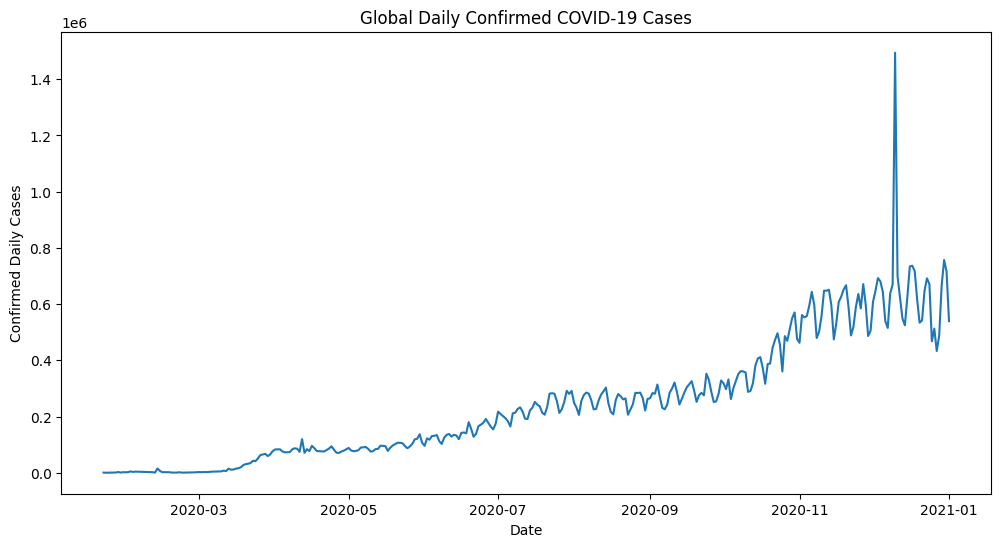

ModuleNotFoundError: No module named 'prophet'

In [36]:
# Step 1: Group global daily confirmed cases
global_data = full_join3.groupby('Date').agg({
    'Confirmed Daily': 'sum'
}).reset_index()

# Step 2: Plot to visualize the global daily cases
plt.figure(figsize=(12,6))
plt.plot(global_data['Date'], global_data['Confirmed Daily'])
plt.title('Global Daily Confirmed COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('Confirmed Daily Cases')
plt.show()

# Step 3: Forecasting using Prophet
from prophet import Prophet

df = global_data[['Date', 'Confirmed Daily']].rename(columns={'Date': 'ds', 'Confirmed Daily': 'y'})

m = Prophet()
m.fit(df)

# Step 4: Make predictions for next 30 days
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Step 5: Plot forecast
m.plot(forecast)
plt.title('COVID-19 Forecast: Confirmed Daily Cases')
plt.show()

# Step 6: Plot forecast components
m.plot_components(forecast)
plt.show()


In [37]:
df = global_data[['Date', 'Confirmed Daily']].rename(columns={'Date': 'ds', 'Confirmed Daily': 'y'})


In [38]:
# Split data (for example, last 30 days as test)
train_df = df[:-30]
test_df = df[-30:]

# Train model on train_df
m = Prophet()
m.fit(train_df)

# Forecast for test period
future_test = m.make_future_dataframe(periods=30)
forecast_test = m.predict(future_test)

# Merge forecast with test data to compare
forecast_test = forecast_test.set_index('ds')
test_df = test_df.set_index('ds')

# Plot actual vs forecast
plt.figure(figsize=(12,6))
plt.plot(test_df.index, test_df['y'], label='Actual')
plt.plot(forecast_test.index[-30:], forecast_test['yhat'][-30:], label='Forecast')
plt.title('Actual vs Forecast (Validation)')
plt.legend()
plt.show()


NameError: name 'Prophet' is not defined

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get real and predicted values
y_true = test_df['y']
y_pred = forecast_test['yhat'][-30:]

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


NameError: name 'test_df' is not defined

In [ ]:
m.plot_components(forecast)
